# Phase 3 · Triple Fusion — Scaleup Version

**Triple Fusion: Image (DenseNet+CBAM) + Text (ClinicalBERT) + Clinical Metadata (MLP)**

| Item | Value |
|---|---|
| Dataset | `phase3_paired_scaleup_final.csv` (~3,763 rows) |
| Phase 1 ckpt | `Phase_1.1v4_PA_crossval_scaleup/best_model_fold5.pth` |
| Phase 2 ckpt | `Phase_2v2_Scaleup/best_v2_model.pth` |
| Clinical features | 17 (16 original + `has_vitals` flag) |
| Baseline to beat | AUC 0.9460 (Phase 2 Scaleup) |

> Validated: 31/31 checks PASS · 100% images on disk · 99.5% bbox coverage

In [1]:
# --- CELL 0: Imports & Reproducibility ---
import os, random, warnings, json, copy, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import AutoTokenizer, AutoModel
import torchxrayvision as xrv

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.5.1+cu121


In [2]:
# --- CELL 1: Configuration & Paths (SCALEUP VERSION) ---
# ============================================================
# Dataset : Full MIMIC-CXR PA scaleup (~3,763 images)
# Phase 1 : Phase_1.1v4_PA_crossval_scaleup (fold 5 checkpoint - best AUC=0.8500)
# Phase 2 : Phase_2v2_Scaleup checkpoint
# Clinical: phase3_paired_scaleup_final.csv (17 features)
# ============================================================

DATASET_DIR  = r'C:\2026\PneumoFusionNet\mimic\main\dataset'
MAIN_DIR     = r'C:\2026\PneumoFusionNet\mimic\main'

# Input data - single merged CSV (text + image + clinical all-in-one)
PAIRED_CSV   = os.path.join(DATASET_DIR, 'phase3_paired_scaleup_final.csv')
BBOX_CSV     = os.path.join(MAIN_DIR, 'outputs', 'Phase_1.1v4_PA_crossval_scaleup', 'lung_bboxes.csv')

# Checkpoints from scaleup runs
P1_CKPT      = os.path.join(MAIN_DIR, 'outputs', 'Phase_1.1v4_PA_crossval_scaleup', 'best_model_fold5.pth')
P2V2_CKPT    = os.path.join(MAIN_DIR, 'outputs', 'Phase_2v2_Scaleup', 'best_v2_model.pth')

# Output
SAVE_DIR     = os.path.join(MAIN_DIR, 'outputs', 'Phase_3_triple_fusion_scaleup')
os.makedirs(SAVE_DIR, exist_ok=True)

# Model hyperparams (unchanged from original)
IMG_SIZE       = 224
MAX_TEXT_LEN   = 256
CLINBERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
IMG_FEAT_DIM   = 1024
TXT_FEAT_DIM   = 768
ATTN_DIM       = 512
ATTN_HEADS     = 8
META_HIDDEN    = 128
META_OUT_DIM   = 64
N_CLINICAL_FEATURES = 17   # 16 original + has_vitals flag

# Training
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
BATCH_SIZE  = 16
LR_FUSION   = 2e-4
LR_BERT     = 1e-5
LR_META     = 1e-3
EPOCHS      = 40
PATIENCE    = 8
FOCAL_GAMMA = 2.0
MIXUP_ALPHA = 0.2
CLASSES     = ['NORMAL', 'PNEUMONIA']
MEAN = [0.5020]; STD = [0.2703]

# Clinical feature columns (17 = 16 original + has_vitals)
CLINICAL_FEATURES = [
    'age', 'gender_M', 'is_deceased',
    'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f',
    'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin',
    'has_vitals'
]

# Image/report path base (relative paths in CSV are relative to DATASET_DIR)
IMG_BASE = DATASET_DIR

print(f'Paired CSV    : {os.path.exists(PAIRED_CSV)} -> {PAIRED_CSV}')
print(f'BBox CSV      : {os.path.exists(BBOX_CSV)}')
print(f'P1 checkpoint : {os.path.exists(P1_CKPT)}')
print(f'P2v2 ckpt     : {os.path.exists(P2V2_CKPT)}')
print(f'Save dir      : {SAVE_DIR}')
print(f'Clinical feats: {N_CLINICAL_FEATURES}')


Paired CSV    : True -> C:\2026\PneumoFusionNet\mimic\main\dataset\phase3_paired_scaleup_final.csv
BBox CSV      : True
P1 checkpoint : True
P2v2 ckpt     : True
Save dir      : C:\2026\PneumoFusionNet\mimic\main\outputs\Phase_3_triple_fusion_scaleup
Clinical feats: 17


In [3]:
# --- CELL 2: Data Loading (SCALEUP - single merged CSV) ---
import re

def resolve_path(p):
    if pd.isna(p) or str(p).strip() == '': return ''
    p = str(p).replace('/', os.sep).replace('\\\\', os.sep)
    return p if os.path.isabs(p) else os.path.join(IMG_BASE, p)

# Load the single merged CSV (text + clinical already combined)
df_raw = pd.read_csv(PAIRED_CSV)
df_raw['image_path']  = df_raw['image_path'].apply(resolve_path)
df_raw['report_path'] = df_raw['report_path'].apply(resolve_path)

# Use raw_report column if available; otherwise read from file
if 'raw_report' in df_raw.columns:
    df_raw['full_report'] = df_raw['raw_report'].fillna('').astype(str)
else:
    def read_report(path):
        try:
            with open(path, encoding='utf-8', errors='ignore') as f: return f.read().strip()
        except: return ''
    df_raw['full_report'] = df_raw['report_path'].apply(read_report)

print(f'Loaded {len(df_raw):,} rows | Labels: {df_raw["label"].value_counts().to_dict()}')
print(f'Clinical columns present: {[c for c in CLINICAL_FEATURES if c in df_raw.columns]}')
print(f'Missing: {[c for c in CLINICAL_FEATURES if c not in df_raw.columns]}')


Loaded 3,763 rows | Labels: {1: 1891, 0: 1872}
Clinical columns present: ['age', 'gender_M', 'is_deceased', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f', 'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin', 'has_vitals']
Missing: []


In [4]:
# --- CELL 3: Text Extraction (FINDINGS + HISTORY) ---
# Same approach as Phase 2v2 - Improvement 1

# SCALEUP FIX: df_raw loaded in Cell 2, alias to text_df for downstream cells
text_df = df_raw.copy()

LEAKAGE_RE = re.compile(
    r'\bpneumonia\b|\bpneumonic\b|\bno[ -]acute[ -]\w+|\bno finding\w*'
    r'|\bcompatible with\b|\bconsistent with\b|\bnormal study\b|\bno significant\b',
    re.IGNORECASE
)

def extract_rich_text(text):
    parts = []
    h = re.search(r'HISTORY[:\s]+(.*?)(?=FINDINGS|TECHNIQUE|COMPARISON|\n\n|\Z)',
                  text, re.DOTALL | re.IGNORECASE)
    if h: parts.append(h.group(1).strip())
    f = re.search(r'FINDINGS[:\s]+(.*?)(?=IMPRESSION|CONCLUSION|\n\n|\Z)',
                  text, re.DOTALL | re.IGNORECASE)
    if f: parts.append(f.group(1).strip())
    result = ' '.join(parts).strip()
    if not result: result = text[:512]
    result = LEAKAGE_RE.sub('[REDACTED]', result)
    return result

def read_report(path):
    try:
        with open(path, encoding='utf-8', errors='ignore') as f:
            return f.read().strip()
    except: return ''

# Use pre-loaded full_report from Cell 2 if available, else read from disk
if 'full_report' not in text_df.columns:
    has_report = text_df['report_path'].apply(os.path.exists)
    print(f'Reports on disk: {has_report.sum()}/{len(text_df)}')
    text_df['full_report'] = text_df['report_path'].apply(read_report)

text_df['report_rich'] = text_df['full_report'].apply(extract_rich_text)
print(f'Reports processed : {len(text_df):,}')
print(f'Avg words (rich)  : {text_df["report_rich"].str.split().str.len().mean():.1f}')

# Verify no empty rich text
empty = (text_df['report_rich'].str.strip() == '').sum()
print(f'Empty report_rich : {empty}')


Reports processed : 3,763
Avg words (rich)  : 50.0
Empty report_rich : 0


In [5]:
# --- CELL 4: Clinical Feature Validation & Missing Summary (SCALEUP) ---
# text_df has: report_rich (from Cell 3) + all clinical cols (pre-merged in CSV)
# Simply use text_df as df — no separate merge needed

df = text_df.copy()

print(f'Rows            : {len(df):,}')
print(f'Columns         : {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['label'].value_counts().rename({0: 'Normal', 1: 'Pneumonia'}))

# Verify report_rich is present
assert 'report_rich' in df.columns, "report_rich missing — re-run Cell 3"
print(f'\nreport_rich present: True')
print(f'Avg words (rich)   : {df["report_rich"].str.split().str.len().mean():.1f}')

# Check which clinical features are present
missing_features = [c for c in CLINICAL_FEATURES if c not in df.columns]
if missing_features:
    print(f'\nWARNING - Missing features: {missing_features}')

CLINICAL_FEATURES_USED = [c for c in CLINICAL_FEATURES if c in df.columns]
N_CLINICAL_FEATURES = len(CLINICAL_FEATURES_USED)
print(f'\nUsing {N_CLINICAL_FEATURES} clinical features: {CLINICAL_FEATURES_USED}')

print(f'\nMissing values per feature (will be imputed in Cell 5):')
for col in CLINICAL_FEATURES_USED:
    n = df[col].isna().sum()
    bar = '#' * int((100 - 100*n/len(df)) / 5)
    print(f'  {col:25s}: {n:4d} ({100*n/len(df):.1f}%) {bar}')


Rows            : 3,763
Columns         : ['subject_id', 'study_id', 'dicom_id', 'image_path', 'report_path', 'label', 'raw_report', 'age', 'gender_M', 'is_deceased', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f', 'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin', 'has_vitals', 'full_report', 'report_rich']

Label distribution:
Pneumonia    1891
Normal       1872
Name: label, dtype: int64

report_rich present: True
Avg words (rich)   : 50.0

Using 17 clinical features: ['age', 'gender_M', 'is_deceased', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f', 'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin', 'has_vitals']

Missing values per feature (will be imputed in Cell 5):
  age                      :  186 (4.9%) ###################
  gender_M                 :   95 (2.5%) ###################
  is_deceased              :  186 (4.9%) #################

In [6]:
# --- CELL 5: Train / Val / Test Split + NaN Imputation + Scaling ---
from sklearn.preprocessing import StandardScaler

# Drop rows with no label
df = df[df['label'].notna()].reset_index(drop=True)
df['label'] = df['label'].astype(int)

# Use only features that exist in df
CLINICAL_FEATURES_USED = [c for c in CLINICAL_FEATURES if c in df.columns]
N_CLINICAL_FEATURES    = len(CLINICAL_FEATURES_USED)
print(f'Clinical features: {N_CLINICAL_FEATURES} -> {CLINICAL_FEATURES_USED}')

# ── Split ──────────────────────────────────────────────────────────────────
train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_frac, stratify=train_val_df['label'], random_state=SEED)

train_df = train_df.copy().reset_index(drop=True)
val_df   = val_df.copy().reset_index(drop=True)
test_df  = test_df.copy().reset_index(drop=True)

for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    n0 = (split['label']==0).sum(); n1 = (split['label']==1).sum()
    print(f'{name:5s}: {len(split):5d}  (Normal={n0}, Pneumonia={n1})')

# ── Step 1: Fill NaN with TRAIN median only (no leakage) ──────────────────
print('\nImputing NaN with train-set median...')
train_medians = {}
for col in CLINICAL_FEATURES_USED:
    median_val = train_df[col].median()
    if pd.isna(median_val):
        median_val = 0.0
    train_medians[col] = median_val
    train_df[col] = train_df[col].fillna(median_val).astype(float)
    val_df[col]   = val_df[col].fillna(median_val).astype(float)
    test_df[col]  = test_df[col].fillna(median_val).astype(float)

# Sanity check
total_nan = sum(
    train_df[c].isna().sum() + val_df[c].isna().sum() + test_df[c].isna().sum()
    for c in CLINICAL_FEATURES_USED)
print(f'NaN after imputation : {total_nan}  (must be 0)')
assert total_nan == 0, f"Still {total_nan} NaN values after imputation!"

# ── Step 2: StandardScaler (fit on train only) ─────────────────────────────
scaler = StandardScaler()
train_df[CLINICAL_FEATURES_USED] = scaler.fit_transform(
    train_df[CLINICAL_FEATURES_USED].astype(float))
val_df[CLINICAL_FEATURES_USED]   = scaler.transform(
    val_df[CLINICAL_FEATURES_USED].astype(float))
test_df[CLINICAL_FEATURES_USED]  = scaler.transform(
    test_df[CLINICAL_FEATURES_USED].astype(float))

# Final check
total_nan_scaled = sum(train_df[c].isna().sum() for c in CLINICAL_FEATURES_USED)
print(f'NaN after scaling    : {total_nan_scaled}  (must be 0)')
assert total_nan_scaled == 0, "NaN after scaling!"

# Update globals so downstream cells (model, dataset) use correct count
CLINICAL_FEATURES   = CLINICAL_FEATURES_USED
N_CLINICAL_FEATURES = len(CLINICAL_FEATURES)
print(f'\nDone. N_CLINICAL_FEATURES = {N_CLINICAL_FEATURES}')
print('Clinical features standardised (fit on train only). No data leakage.')


Clinical features: 17 -> ['age', 'gender_M', 'is_deceased', 'heart_rate', 'respiratory_rate', 'spo2', 'systolic_bp', 'diastolic_bp', 'temperature_f', 'wbc', 'hemoglobin', 'hematocrit', 'creatinine', 'crp', 'alk_phos', 'albumin', 'has_vitals']
Train:  2633  (Normal=1310, Pneumonia=1323)
Val  :   565  (Normal=281, Pneumonia=284)
Test :   565  (Normal=281, Pneumonia=284)

Imputing NaN with train-set median...
NaN after imputation : 0  (must be 0)
NaN after scaling    : 0  (must be 0)

Done. N_CLINICAL_FEATURES = 17
Clinical features standardised (fit on train only). No data leakage.


In [7]:
# --- CELL 6: Bbox Lookup & Triple Dataset Class ---
bbox_df     = pd.read_csv(BBOX_CSV)
bbox_lookup = bbox_df.set_index('image_path').to_dict('index')
print(f'Bbox entries: {len(bbox_lookup)}')

class TripleModalCXRDataset(Dataset):
    """Dataset returning (image, text_ids, text_mask, clinical_features, label)"""
    def __init__(self, df, bbox_lookup, tokenizer, img_transform,
                 clinical_features, max_len=MAX_TEXT_LEN):
        self.df               = df.reset_index(drop=True)
        self.bbox_lookup      = bbox_lookup
        self.tokenizer        = tokenizer
        self.transform        = img_transform
        self.clinical_features = clinical_features
        self.max_len          = max_len
        self.clahe            = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- IMAGE ---
        img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((224,224), dtype=np.uint8)
        img = self.clahe.apply(img)
        bb  = self.bbox_lookup.get(row.image_path, None)
        if bb and bb.get('x_max',0)>0:
            img = img[bb['y_min']:bb['y_max'], bb['x_min']:bb['x_max']]
        img = self.transform(Image.fromarray(img))

        # --- TEXT ---
        enc = self.tokenizer(
            row.report_rich, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )

        # --- CLINICAL METADATA ---
        meta = torch.tensor(
            [float(row[c]) for c in self.clinical_features],
            dtype=torch.float32
        )

        return (
            img,
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            meta,
            int(row.label)
        )

    def set_transform(self, t): self.transform = t

val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
print('Dataset class ready.')

Bbox entries: 3744
Dataset class ready.


In [8]:
# --- CELL 7: Model Architecture ---

# ---- CBAM (same as Phase 1 & 2) ----
class ChannelAttention(nn.Module):
    def __init__(self, c, r=16):
        super().__init__()
        self.avg=nn.AdaptiveAvgPool2d(1); self.max=nn.AdaptiveMaxPool2d(1)
        self.mlp=nn.Sequential(nn.Conv2d(c,c//r,1,bias=False),nn.ReLU(True),nn.Conv2d(c//r,c,1,bias=False))
        self.sig=nn.Sigmoid()
    def forward(self,x): return x*self.sig(self.mlp(self.avg(x))+self.mlp(self.max(x)))

class SpatialAttention(nn.Module):
    def __init__(self,k=7):
        super().__init__()
        self.conv=nn.Conv2d(2,1,k,padding=k//2,bias=False); self.sig=nn.Sigmoid()
    def forward(self,x):
        return x*self.sig(self.conv(torch.cat([x.mean(1,keepdim=True),x.max(1,keepdim=True)[0]],1)))

class CBAM(nn.Module):
    def __init__(self,c,r=16):
        super().__init__()
        self.ca=ChannelAttention(c,r); self.sa=SpatialAttention()
    def forward(self,x): return self.sa(self.ca(x))

# ---- Image Encoder (Phase-1 frozen) -- SAME AS PHASE 2v2 ----
class ImageEncoder(nn.Module):
    def __init__(self, ckpt):
        super().__init__()
        xrv_m=xrv.models.DenseNet(weights='densenet121-res224-all')
        self.features=xrv_m.features; self.cbam=CBAM(1024); self.pool=nn.AdaptiveAvgPool2d(1)
        sd={k:v for k,v in torch.load(ckpt,map_location='cpu').items()
            if k.startswith('features.') or k.startswith('cbam.')}
        miss,unexp=self.load_state_dict(sd,strict=False)
        print(f'[ImageEncoder] loaded {len(sd)} keys | missing={len(miss)} unexpected={len(unexp)}')
        for p in self.parameters(): p.requires_grad=False
    def forward(self,x):
        f=F.relu(self.features(x),True); f=self.cbam(f)
        return self.pool(f).flatten(1)       # (B,1024)
    def get_feature_maps(self,x):
        return F.relu(self.cbam(self.features(x)),True)  # (B,1024,H,W) for Grad-CAM

# ---- Text Encoder: ClinicalBERT (last 2 layers unfrozen) -- SAME AS PHASE 2v2 ----
class TextEncoder(nn.Module):
    def __init__(self, model_name=CLINBERT_MODEL):
        super().__init__()
        self.bert=AutoModel.from_pretrained(model_name)
        for name,p in self.bert.named_parameters():
            if 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'pooler' in name:
                p.requires_grad=True
            else:
                p.requires_grad=False
        trainable=sum(p.numel() for p in self.bert.parameters() if p.requires_grad)
        print(f'[TextEncoder] Unfrozen BERT params: {trainable:,}')
    def forward(self,input_ids,attention_mask):
        out=self.bert(input_ids=input_ids,attention_mask=attention_mask)
        return out.last_hidden_state   # (B, seq_len, 768)

# ---- NEW: Metadata Encoder MLP ----
class MetadataEncoder(nn.Module):
    """Small MLP: 16 clinical features → 128 → 64-d embedding"""
    def __init__(self, in_dim=N_CLINICAL_FEATURES, hidden=META_HIDDEN, out_dim=META_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, out_dim),
            nn.ReLU()
        )
        trainable = sum(p.numel() for p in self.net.parameters())
        print(f'[MetadataEncoder] Trainable params: {trainable:,}')
    def forward(self, x):
        return self.net(x)  # (B, META_OUT_DIM=64)

# ---- Triple Fusion Net (extends Phase 2v2 CrossAttnFusionNet + metadata) ----
class TripleFusionNet(nn.Module):
    """
    Fuses:
      - img_feat    (B, 1024) from DenseNet+CBAM
      - txt_tokens  (B, seq, 768) from ClinicalBERT
      - meta        (B, 16) clinical metadata

    Cross-Attention: image queries text → (B, 512)
    Triple concat: [img(1024) + cross_attn(512) + meta(64)] = 1600-d
    Classifier: LayerNorm → Dropout → Linear chain → 2 logits
    """
    def __init__(self,
                 img_dim=IMG_FEAT_DIM,
                 txt_dim=TXT_FEAT_DIM,
                 attn_dim=ATTN_DIM,
                 heads=ATTN_HEADS,
                 meta_out=META_OUT_DIM):
        super().__init__()
        # Cross-attention components (same as Phase 2v2)
        self.query_proj = nn.Linear(img_dim, attn_dim)
        self.key_proj   = nn.Linear(txt_dim, attn_dim)
        self.val_proj   = nn.Linear(txt_dim, attn_dim)
        self.cross_attn = nn.MultiheadAttention(attn_dim, heads, batch_first=True, dropout=0.1)
        self.norm1      = nn.LayerNorm(attn_dim)

        # Triple fusion classifier (1024 + 512 + 64 = 1600)
        fused_dim = img_dim + attn_dim + meta_out  # 1600
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Dropout(0.4),
            nn.Linear(fused_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        print(f'[TripleFusionNet] fused_dim={fused_dim} (img={img_dim} + attn={attn_dim} + meta={meta_out})')

    def forward(self, img_feat, txt_tokens, meta_feat):
        # img_feat   : (B, 1024)
        # txt_tokens : (B, seq_len, 768)
        # meta_feat  : (B, 64)
        q = self.query_proj(img_feat).unsqueeze(1)   # (B, 1, 512)
        k = self.key_proj(txt_tokens)                 # (B, seq, 512)
        v = self.val_proj(txt_tokens)                 # (B, seq, 512)
        attended, _ = self.cross_attn(q, k, v)        # (B, 1, 512)
        attended = self.norm1(attended.squeeze(1))     # (B, 512)

        fused = torch.cat([img_feat, attended, meta_feat], dim=1)  # (B, 1600)
        return self.classifier(fused)

print('All model classes defined.')

All model classes defined.


In [9]:
# --- CELL 8: Focal Loss & Triple Mixup Utilities ---

class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA, weight=None):
        super().__init__()
        self.gamma=gamma; self.weight=weight
    def forward(self, logits, labels):
        ce  = F.cross_entropy(logits, labels, weight=self.weight, reduction='none')
        pt  = torch.exp(-ce)
        loss= ((1-pt)**self.gamma * ce).mean()
        return loss

def mixup_triple(img_feat, txt_tokens, meta_feat, labels, alpha=MIXUP_ALPHA):
    """Mixup on all three embedding branches simultaneously"""
    if alpha <= 0: return img_feat, txt_tokens, meta_feat, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(img_feat.size(0), device=img_feat.device)
    img_mix  = lam * img_feat   + (1-lam) * img_feat[idx]
    txt_mix  = lam * txt_tokens + (1-lam) * txt_tokens[idx]
    meta_mix = lam * meta_feat  + (1-lam) * meta_feat[idx]
    return img_mix, txt_mix, meta_mix, labels, labels[idx], lam

def mixup_criterion(criterion, logits, labels_a, labels_b, lam):
    return lam * criterion(logits, labels_a) + (1-lam) * criterion(logits, labels_b)

print('Focal Loss and Triple Mixup ready.')

Focal Loss and Triple Mixup ready.


In [10]:
# --- CELL 9: Instantiate Models, Load Phase 2v2 Weights, Build DataLoaders ---

print('Loading ClinicalBERT tokenizer...')
tokenizer     = AutoTokenizer.from_pretrained(CLINBERT_MODEL)
text_encoder  = TextEncoder(CLINBERT_MODEL).to(DEVICE)

print('Loading Phase-1 Image Encoder (Fold 5 - best AUC=0.8500)...')
image_encoder = ImageEncoder(P1_CKPT).to(DEVICE)

print('Building MetadataEncoder...')
meta_encoder  = MetadataEncoder(in_dim=N_CLINICAL_FEATURES).to(DEVICE)

print('Building TripleFusionNet...')
fusion_model  = TripleFusionNet().to(DEVICE)

# --- Load Phase 2v2 weights into text_encoder and cross-attn components ---
print(f'\nLoading Phase 2v2 checkpoint: {P2V2_CKPT}')
if os.path.exists(P2V2_CKPT):
    p2v2_state = torch.load(P2V2_CKPT, map_location='cpu')

    # Load BERT weights from Phase 2v2 (text encoder was fine-tuned)
    if 'text' in p2v2_state:
        miss, unexp = text_encoder.load_state_dict(p2v2_state['text'], strict=False)
        print(f'  [TextEncoder] Loaded P2v2 weights | missing={len(miss)} unexpected={len(unexp)}')

    # Load cross-attention + classifier weights from Phase 2v2
    # (query_proj, key_proj, val_proj, cross_attn, norm1 are compatible)
    if 'fusion' in p2v2_state:
        fusion_p2v2 = p2v2_state['fusion']
        # Only load the cross-attention keys (not classifier — it changed from 1536 to 1600)
        ca_keys = {k:v for k,v in fusion_p2v2.items()
                   if any(k.startswith(pfx) for pfx in
                          ['query_proj','key_proj','val_proj','cross_attn','norm1'])}
        miss2, unexp2 = fusion_model.load_state_dict(ca_keys, strict=False)
        print(f'  [FusionNet] Loaded {len(ca_keys)} cross-attn keys from P2v2 | '
              f'missing={len(miss2)} unexpected={len(unexp2)}')
        print(f'  (Classifier head re-initialised: 1536-d → 1600-d for triple fusion)')
else:
    print(f'  WARNING: P2v2 checkpoint not found. Training from scratch!')

trainable_fusion = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
trainable_bert   = sum(p.numel() for p in text_encoder.parameters() if p.requires_grad)
trainable_meta   = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad)
print(f'\nTrainable params:')
print(f'  Fusion Net   : {trainable_fusion:,}')
print(f'  BERT (unfrozen): {trainable_bert:,}')
print(f'  Metadata MLP : {trainable_meta:,}')

# --- DataLoaders ---
train_ds = TripleModalCXRDataset(train_df, bbox_lookup, tokenizer, train_tfm, CLINICAL_FEATURES)
val_ds   = TripleModalCXRDataset(val_df,   bbox_lookup, tokenizer, val_tfm,   CLINICAL_FEATURES)
test_ds  = TripleModalCXRDataset(test_df,  bbox_lookup, tokenizer, val_tfm,   CLINICAL_FEATURES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'\nTrain batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Loading ClinicalBERT tokenizer...
[TextEncoder] Unfrozen BERT params: 14,766,336
Loading Phase-1 Image Encoder (Fold 5 - best AUC=0.8500)...
[ImageEncoder] loaded 728 keys | missing=3 unexpected=3
Building MetadataEncoder...
[MetadataEncoder] Trainable params: 27,072
Building TripleFusionNet...
[TripleFusionNet] fused_dim=1600 (img=1024 + attn=512 + meta=64)

Loading Phase 2v2 checkpoint: C:\2026\PneumoFusionNet\mimic\main\outputs\Phase_2v2_Scaleup\best_v2_model.pth
  [TextEncoder] Loaded P2v2 weights | missing=0 unexpected=0
  [FusionNet] Loaded 12 cross-attn keys from P2v2 | missing=8 unexpected=0
  (Classifier head re-initialised: 1536-d → 1600-d for triple fusion)

Trainable params:
  Fusion Net   : 3,252,738
  BERT (unfrozen): 14,766,336
  Metadata MLP : 27,072

Train batches: 165 | Val: 36 | Test: 36


In [11]:
# --- CELL 10: Training Loop ---

def eval_epoch(fusion, img_enc, txt_enc, meta_enc, loader, criterion, device):
    fusion.eval(); img_enc.eval(); txt_enc.eval(); meta_enc.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs,ids,masks,meta,labels in loader:
            imgs   = imgs.to(device)
            ids    = ids.to(device)
            masks  = masks.to(device)
            meta   = meta.to(device)
            labels = labels.to(device)

            img_f   = img_enc(imgs)            # (B, 1024)
            txt_t   = txt_enc(ids, masks)      # (B, seq, 768)
            meta_f  = meta_enc(meta)           # (B, 64)
            logits  = fusion(img_f, txt_t, meta_f)

            loss  = criterion(logits, labels)
            probs = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            total_loss += loss.item()*labels.size(0)
            all_probs.extend(probs); all_labels.extend(labels.cpu().tolist())

    acc = accuracy_score(all_labels,[1 if p>=0.5 else 0 for p in all_probs])
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels))>1 else 0.5
    return total_loss/len(all_labels), acc, auc, all_probs, all_labels

def find_optimal_threshold(labels, probs):
    fpr,tpr,thresh=roc_curve(labels,probs)
    return float(thresh[np.argmax(tpr-fpr)])

def find_clinical_threshold(labels, probs, target_sens=0.90):
    fpr,tpr,thresh=roc_curve(labels,probs)
    for t,s in zip(thresh, tpr):
        if s >= target_sens:
            return float(t)
    return float(thresh[np.argmax(tpr-fpr)])

# Class weights
n0=(train_df['label']==0).sum(); n1=(train_df['label']==1).sum()
weight=torch.tensor([n1/(n0+n1), n0/(n0+n1)], dtype=torch.float).to(DEVICE)
criterion_focal = FocalLoss(gamma=FOCAL_GAMMA, weight=weight)

# Optimizer with 3 separate learning rates
optimizer = torch.optim.AdamW([
    {'params': text_encoder.parameters(),  'lr': LR_BERT,   'weight_decay': 1e-4},
    {'params': fusion_model.parameters(),  'lr': LR_FUSION, 'weight_decay': 1e-4},
    {'params': meta_encoder.parameters(),  'lr': LR_META,   'weight_decay': 1e-3},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_auc, best_state, patience_cnt = 0.0, None, 0
history = {'train_loss':[], 'val_loss':[], 'train_auc':[], 'val_auc':[]}

for epoch in range(1, EPOCHS+1):
    # ---- Train ----
    fusion_model.train(); image_encoder.eval(); text_encoder.train(); meta_encoder.train()
    ep_loss, ep_probs, ep_labels = 0.0, [], []

    for imgs,ids,masks,meta,labels in train_loader:
        imgs   = imgs.to(DEVICE)
        ids    = ids.to(DEVICE)
        masks  = masks.to(DEVICE)
        meta   = meta.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            img_f = image_encoder(imgs)       # (B, 1024) - frozen
        txt_t  = text_encoder(ids, masks)     # (B, seq, 768) - partially trainable
        meta_f = meta_encoder(meta)           # (B, 64) - trainable

        # Triple Mixup on all embeddings
        img_m, txt_m, meta_m, la, lb, lam = mixup_triple(img_f, txt_t, meta_f, labels)

        optimizer.zero_grad()
        logits = fusion_model(img_m, txt_m, meta_m)
        loss   = mixup_criterion(criterion_focal, logits, la, lb, lam)
        loss.backward()

        all_params = (list(fusion_model.parameters()) +
                      list(text_encoder.parameters()) +
                      list(meta_encoder.parameters()))
        nn.utils.clip_grad_norm_(all_params, 1.0)
        optimizer.step()

        probs = F.softmax(logits.detach(), dim=1)[:,1].cpu().numpy()
        ep_loss += loss.item()*labels.size(0)
        ep_probs.extend(probs); ep_labels.extend(labels.cpu().tolist())

    scheduler.step()
    tr_loss = ep_loss/len(ep_labels)
    tr_auc  = roc_auc_score(ep_labels, ep_probs) if len(set(ep_labels))>1 else 0.5

    # ---- Val ----
    val_loss,val_acc,val_auc,_,_ = eval_epoch(
        fusion_model, image_encoder, text_encoder, meta_encoder,
        val_loader, criterion_focal, DEVICE)

    history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['train_auc'].append(tr_auc);   history['val_auc'].append(val_auc)

    marker=''
    if val_auc > best_auc:
        best_auc=val_auc
        best_state=copy.deepcopy({
            'fusion': fusion_model.state_dict(),
            'text':   text_encoder.state_dict(),
            'meta':   meta_encoder.state_dict()
        })
        torch.save(best_state, os.path.join(SAVE_DIR,'best_p3_model.pth'))
        patience_cnt=0; marker=' <-- best'
    else:
        patience_cnt+=1

    if epoch%5==0 or marker:
        print(f'Ep {epoch:03d} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} '
              f'| val_auc={val_auc:.4f} val_acc={val_acc:.3f}{marker}')
    if patience_cnt>=PATIENCE:
        print(f'Early stop at epoch {epoch}.'); break

print(f'Best Val AUC: {best_auc:.4f}')

Ep 001 | tr_loss=0.0171 tr_auc=0.7753 | val_auc=0.9673 val_acc=0.899 <-- best
Ep 005 | tr_loss=0.0138 tr_auc=0.7776 | val_auc=0.9642 val_acc=0.878
Early stop at epoch 9.
Best Val AUC: 0.9673


In [12]:
# --- CELL 11: Test Set Evaluation ---
fusion_model.load_state_dict(best_state['fusion'])
text_encoder.load_state_dict(best_state['text'])
meta_encoder.load_state_dict(best_state['meta'])

_,test_acc,test_auc,test_probs,test_labels = eval_epoch(
    fusion_model, image_encoder, text_encoder, meta_encoder,
    test_loader, criterion_focal, DEVICE)

thresh_youden   = find_optimal_threshold(test_labels, test_probs)
thresh_clinical = find_clinical_threshold(test_labels, test_probs, target_sens=0.90)

preds_def      = [1 if p>=0.5            else 0 for p in test_probs]
preds_youden   = [1 if p>=thresh_youden  else 0 for p in test_probs]
preds_clinical = [1 if p>=thresh_clinical else 0 for p in test_probs]

def metrics(labels, preds, name, thresh):
    cm = confusion_matrix(labels, preds)
    s  = cm[1,1]/(cm[1,0]+cm[1,1]) if (cm[1,0]+cm[1,1])>0 else 0
    sp = cm[0,0]/(cm[0,0]+cm[0,1]) if (cm[0,0]+cm[0,1])>0 else 0
    ac = (cm[0,0]+cm[1,1])/cm.sum()
    f1 = f1_score(labels, preds)
    print(f'{name} (thresh={thresh:.3f}): Acc={ac:.3f} F1={f1:.3f} Sens={s:.3f} Spec={sp:.3f}')
    return s, sp, ac, f1

print(f'Test AUC: {test_auc:.4f}\n')
s_d,sp_d,ac_d,f1_d     = metrics(test_labels, preds_def,      'Default  ', 0.5)
s_y,sp_y,ac_y,f1_y     = metrics(test_labels, preds_youden,   'Youden-J ', thresh_youden)
s_c,sp_c,ac_c,f1_c     = metrics(test_labels, preds_clinical, 'Clinical ', thresh_clinical)

Test AUC: 0.9690

Default   (thresh=0.500): Acc=0.908 F1=0.908 Sens=0.905 Spec=0.911
Youden-J  (thresh=0.540): Acc=0.917 F1=0.915 Sens=0.891 Spec=0.943
Clinical  (thresh=0.511): Acc=0.913 F1=0.913 Sens=0.901 Spec=0.925


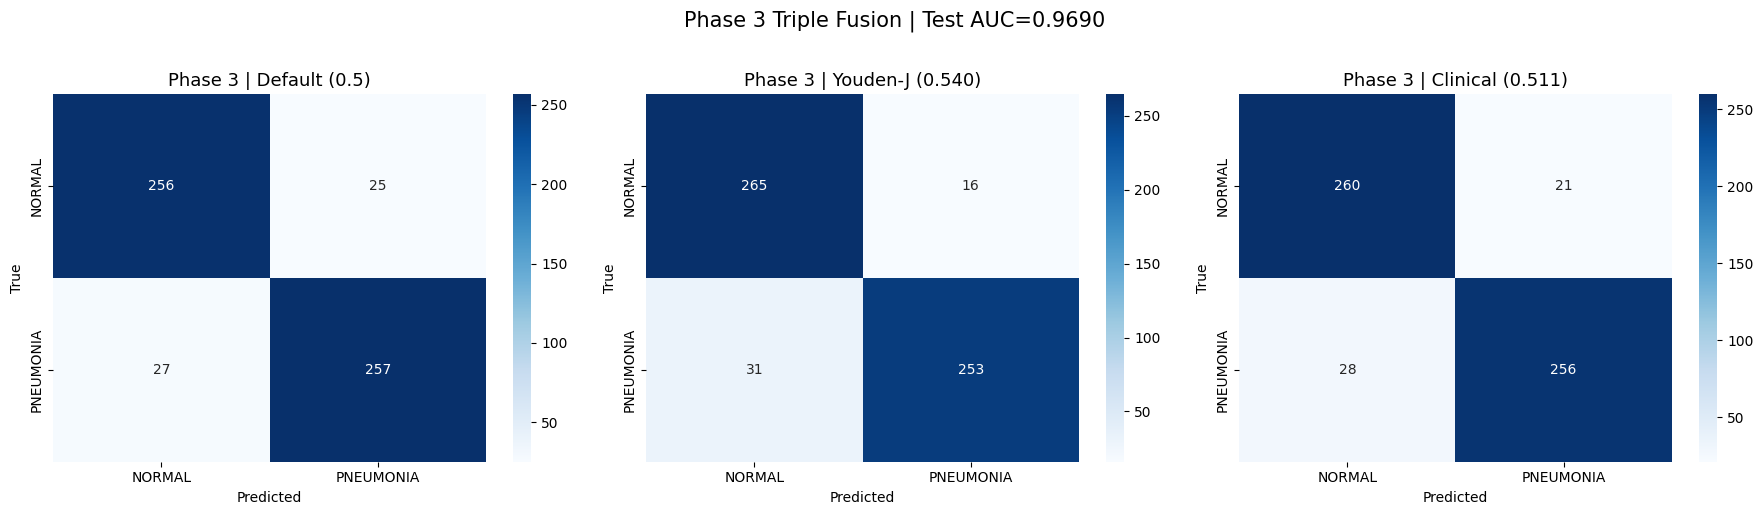

Saved confusion matrices.


In [13]:
# --- CELL 12: Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes,
    [preds_def, preds_youden, preds_clinical],
    ['Default (0.5)', f'Youden-J ({thresh_youden:.3f})', f'Clinical ({thresh_clinical:.3f})']):
    cm_arr = confusion_matrix(test_labels, preds)
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f'Phase 3 | {title}', fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle(f'Phase 3 Triple Fusion | Test AUC={test_auc:.4f}', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_confusion_matrices.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved confusion matrices.')

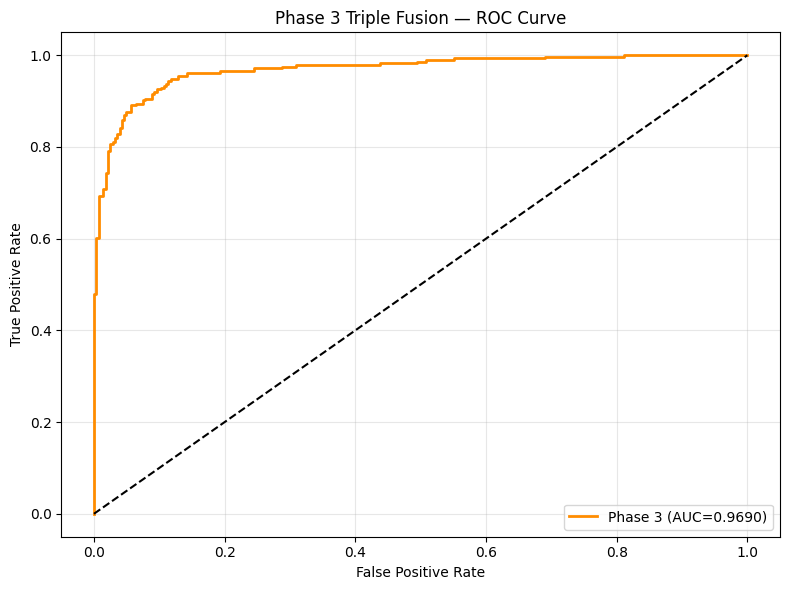

Saved ROC curve.


In [14]:
# --- CELL 13: ROC Curve ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, color='darkorange', label=f'Phase 3 (AUC={test_auc:.4f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Phase 3 Triple Fusion — ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_roc_curve.png'), dpi=150)
plt.show()
print('Saved ROC curve.')

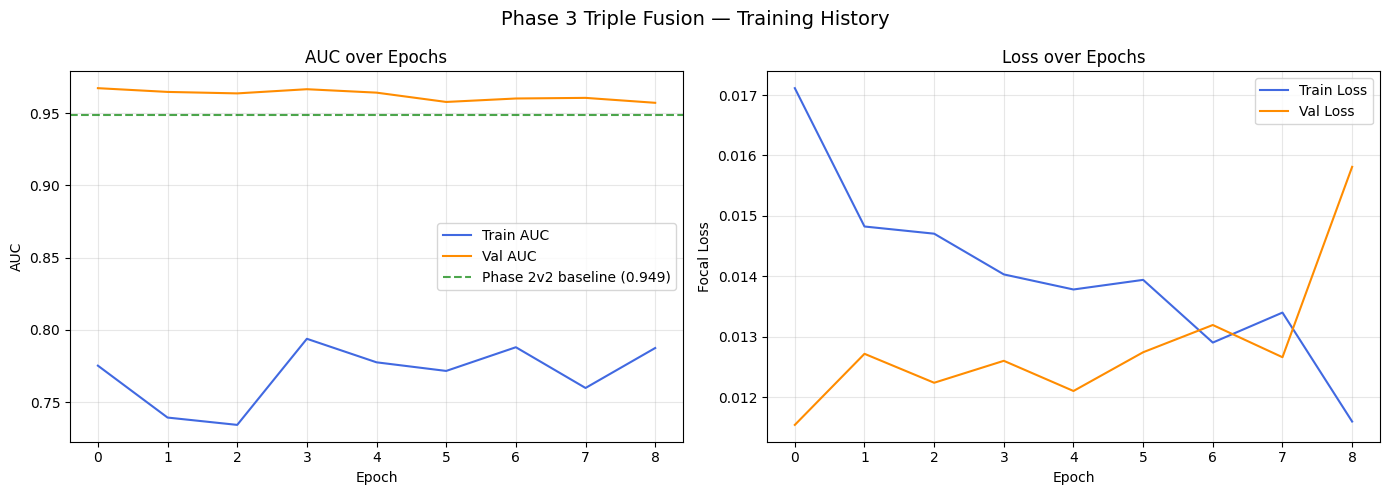

Saved training curves.


In [15]:
# --- CELL 14: Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_auc'], label='Train AUC', color='royalblue')
axes[0].plot(history['val_auc'],   label='Val AUC',   color='darkorange')
axes[0].axhline(0.949, ls='--', color='green', alpha=0.7, label='Phase 2v2 baseline (0.949)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].set_title('AUC over Epochs'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss', color='royalblue')
axes[1].plot(history['val_loss'],   label='Val Loss',   color='darkorange')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Focal Loss')
axes[1].set_title('Loss over Epochs'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 3 Triple Fusion — Training History', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_training_curves.png'), dpi=150)
plt.show()
print('Saved training curves.')

Computing clinical feature importances via permutation...
Baseline AUC: 0.9690


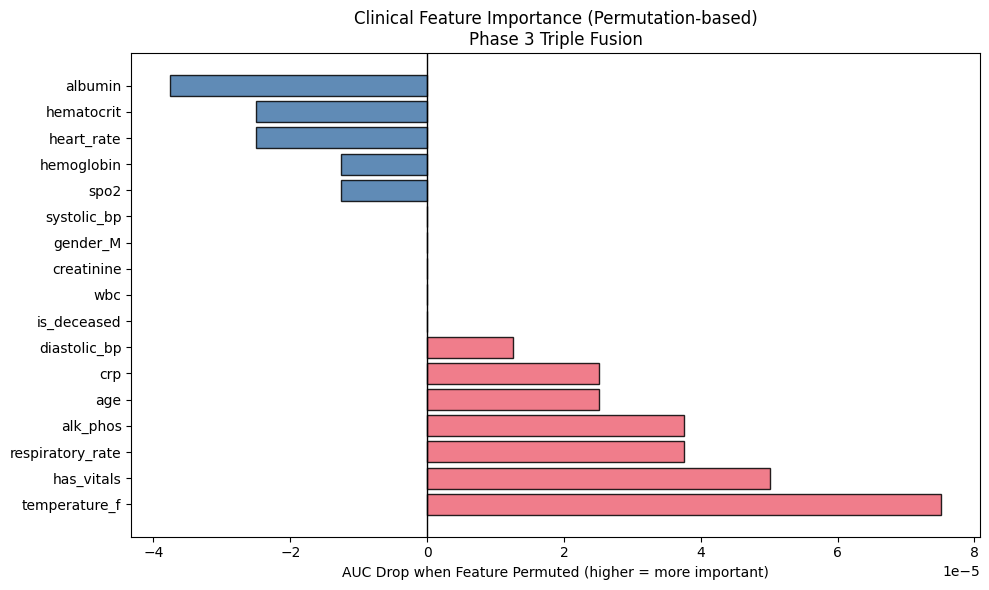


Feature Importances:
  temperature_f       : +0.0001
  has_vitals          : +0.0001
  respiratory_rate    : +0.0000
  alk_phos            : +0.0000
  age                 : +0.0000
  crp                 : +0.0000
  diastolic_bp        : +0.0000
  is_deceased         : +0.0000
  wbc                 : +0.0000
  creatinine          : +0.0000
  gender_M            : -0.0000
  systolic_bp         : -0.0000
  spo2                : -0.0000
  hemoglobin          : -0.0000
  heart_rate          : -0.0000
  hematocrit          : -0.0000
  albumin             : -0.0000


In [17]:
# --- CELL 15: Clinical Feature Importance (Permutation-based) ---
print('Computing clinical feature importances via permutation...')

fusion_model.eval(); image_encoder.eval(); text_encoder.eval(); meta_encoder.eval()

# Baseline AUC
_,_,baseline_auc,_,_ = eval_epoch(
    fusion_model, image_encoder, text_encoder, meta_encoder,
    test_loader, criterion_focal, DEVICE)
print(f'Baseline AUC: {baseline_auc:.4f}')

feature_importances = {}
for feat_idx, feat_name in enumerate(CLINICAL_FEATURES):
    # Evaluate with this feature permuted
    all_probs_perm, all_labels_perm = [], []
    with torch.no_grad():
        for imgs,ids,masks,meta,labels in test_loader:
            imgs   = imgs.to(DEVICE)
            ids    = ids.to(DEVICE)
            masks  = masks.to(DEVICE)
            meta   = meta.clone().to(DEVICE)
            labels = labels.to(DEVICE)

            # Permute this specific feature
            perm_idx = torch.randperm(meta.size(0))
            meta[:, feat_idx] = meta[perm_idx, feat_idx]

            img_f  = image_encoder(imgs)
            txt_t  = text_encoder(ids, masks)
            meta_f = meta_encoder(meta)
            logits = fusion_model(img_f, txt_t, meta_f)
            probs  = F.softmax(logits, dim=1)[:,1].cpu().numpy()
            all_probs_perm.extend(probs)
            all_labels_perm.extend(labels.cpu().tolist())

    perm_auc = roc_auc_score(all_labels_perm, all_probs_perm)
    feature_importances[feat_name] = baseline_auc - perm_auc

# Sort and plot
sorted_feats = sorted(feature_importances.items(), key=lambda x: x[1], reverse=True)
feat_names = [f[0] for f in sorted_feats]
feat_imps  = [f[1] for f in sorted_feats]

plt.figure(figsize=(10, 6))
colors_bar = ['#EE6677' if v > 0 else '#4477AA' for v in feat_imps]
plt.barh(feat_names, feat_imps, color=colors_bar, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', lw=1)
plt.xlabel('AUC Drop when Feature Permuted (higher = more important)')
plt.title('Clinical Feature Importance (Permutation-based)\nPhase 3 Triple Fusion')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'p3_feature_importance.png'), dpi=150)
plt.show()
print('\nFeature Importances:')
for name, imp in sorted_feats:
    print(f'  {name:20s}: {imp:+.4f}')

In [18]:
# --- CELL 16: Save Results JSON & Config ---

results = {
    'phase': 3,
    'description': 'Triple Fusion: Image + Text + Clinical Metadata',
    'architecture': {
        'image_encoder':  'DenseNet121+CBAM (frozen from Phase 1.1v4 Fold 5)',
        'text_encoder':   'Bio_ClinicalBERT (last 2 layers unfrozen)',
        'meta_encoder':   f'MLP({N_CLINICAL_FEATURES}->128->128->{META_OUT_DIM})',
        'fusion':         'CrossAttention(img queries text) + concat meta + MLP classifier',
        'fused_dim':      IMG_FEAT_DIM + ATTN_DIM + META_OUT_DIM,
        'clinical_feats': CLINICAL_FEATURES,
        'p2v2_weights_loaded': os.path.exists(P2V2_CKPT)
    },
    'training': {
        'n_train': len(train_df), 'n_val': len(val_df), 'n_test': len(test_df),
        'batch_size': BATCH_SIZE, 'epochs_run': len(history['val_auc']),
        'lr_fusion': LR_FUSION, 'lr_bert': LR_BERT, 'lr_meta': LR_META,
        'focal_gamma': FOCAL_GAMMA, 'mixup_alpha': MIXUP_ALPHA
    },
    'results': {
        'test_auc':           round(test_auc, 4),
        'best_val_auc':       round(best_auc, 4),
        'default_acc':        round(ac_d, 4),
        'default_sensitivity': round(s_d, 4),
        'default_specificity': round(sp_d, 4),
        'youden_threshold':   round(thresh_youden, 4),
        'youden_acc':         round(ac_y, 4),
        'youden_sensitivity': round(s_y, 4),
        'youden_specificity': round(sp_y, 4),
        'clinical_threshold': round(thresh_clinical, 4),
        'clinical_acc':       round(ac_c, 4),
        'clinical_sensitivity': round(s_c, 4),
        'clinical_specificity': round(sp_c, 4),
        'n_test': len(test_labels)
    },
    'feature_importances': {k: round(v, 4) for k, v in feature_importances.items()},
    'comparison_vs_p2v2': {
        'p2v2_auc':      0.949,
        'p3_auc':        round(test_auc, 4),
        'auc_delta':     round(test_auc - 0.949, 4),
        'p2v2_sens':     0.914,
        'p3_sens':       round(s_y, 4),
        'sens_delta':    round(s_y - 0.914, 4)
    }
}

out_path = os.path.join(SAVE_DIR, 'phase3_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

print('='*60)
print('PHASE 3 TRIPLE FUSION — FINAL RESULTS')
print('='*60)
print(f'Test AUC         : {test_auc:.4f}')
print(f'Sensitivity (Y-J): {s_y*100:.1f}%')
print(f'Specificity (Y-J): {sp_y*100:.1f}%')
print(f'Accuracy    (Y-J): {ac_y*100:.1f}%')
print(f'\nvs Phase 2v2:')
print(f'  AUC delta  : {test_auc-0.949:+.4f}')
print(f'  Sens delta : {s_y-0.914:+.3f}')
print(f'\nResults saved to: {out_path}')

PHASE 3 TRIPLE FUSION — FINAL RESULTS
Test AUC         : 0.9690
Sensitivity (Y-J): 89.1%
Specificity (Y-J): 94.3%
Accuracy    (Y-J): 91.7%

vs Phase 2v2:
  AUC delta  : +0.0200
  Sens delta : -0.023

Results saved to: C:\2026\PneumoFusionNet\mimic\main\outputs\Phase_3_triple_fusion_scaleup\phase3_results.json


Phase 3 Scaleup loaded: AUC=0.969


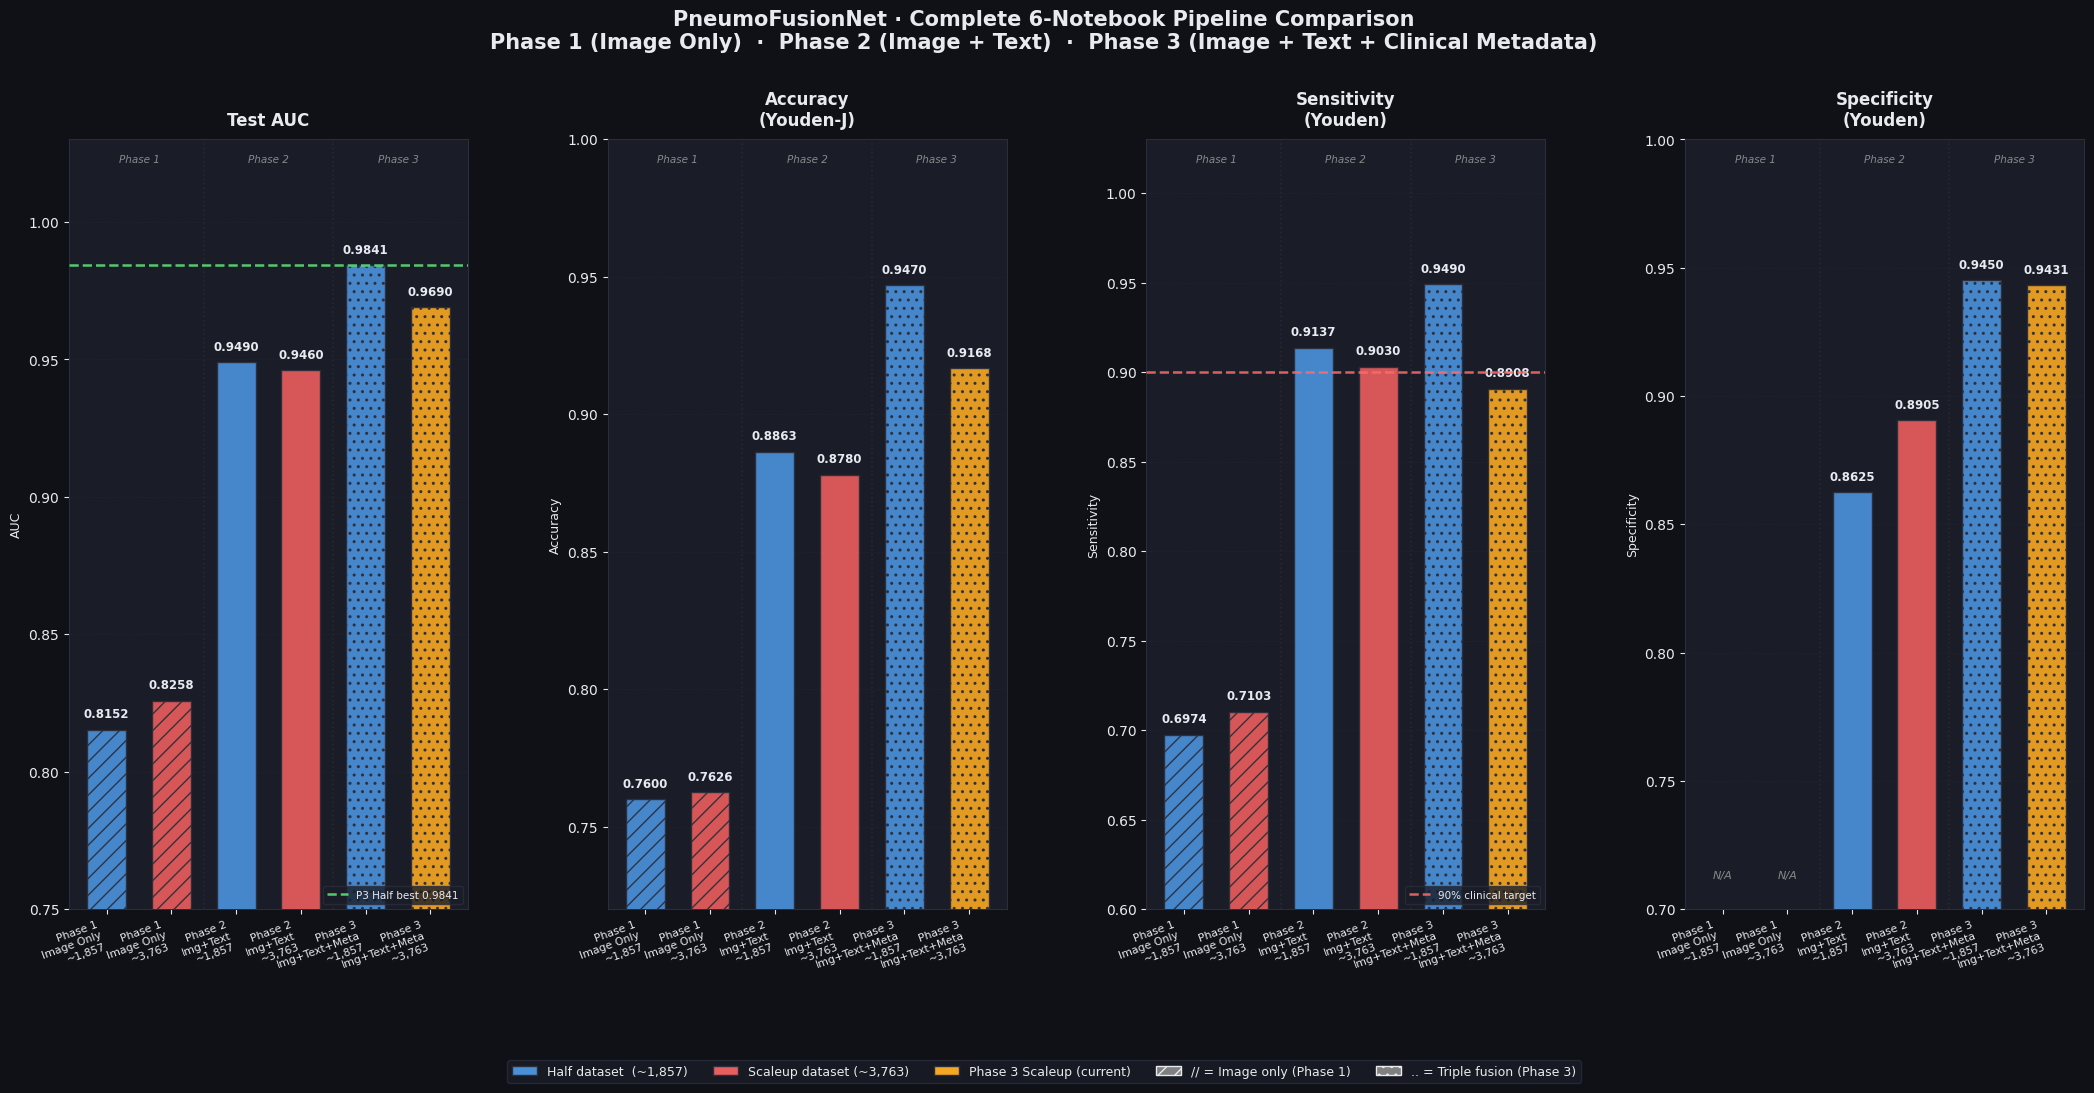


  PneumoFusionNet · COMPLETE PIPELINE COMPARISON (All 6 Notebooks)
  Model                                      Dataset                  AUC     Acc    Sens    Spec
  ----------------------------------------------------------------------------------
  Phase 1 Image Only ~1,857                  Half (~1,857)         0.8152  0.7600  0.6974     N/A
  Phase 1 Image Only ~3,763                  Scaleup (~3,763)      0.8258  0.7626  0.7103     N/A
  Phase 2 Img+Text ~1,857                    Half (~1,857)         0.9490  0.8863  0.9137  0.8625
  Phase 2 Img+Text ~3,763                    Scaleup (~3,763)      0.9460  0.8780  0.9030  0.8905
  Phase 3 Img+Text+Meta ~1,857               Half (~1,857)         0.9841  0.9470  0.9490  0.9450
  Phase 3 Img+Text+Meta ~3,763               Scaleup (~3,763)      0.9690  0.9168  0.8908  0.9431

  IMPROVEMENT: Phase 3 vs Phase 2 (same dataset)
  Comparison                                        ΔAUC    ΔSens    ΔSpec
  ----------------------------------

In [20]:
# --- CELL 17: Full 6-Notebook Pipeline Comparison — All 6 Notebooks ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np, json, os

# ── Load Phase 3 Scaleup result from saved JSON ───────────────────────────────
P3S_JSON = os.path.join(
    r'C:\2026\PneumoFusionNet\mimic\main\outputs\Phase_3_triple_fusion_scaleup',
    'phase3_results.json')

if os.path.exists(P3S_JSON):
    with open(P3S_JSON) as f: p3s = json.load(f)
    p3s_auc  = p3s['results']['test_auc']
    p3s_acc  = p3s['results']['youden_acc']
    p3s_sens = p3s['results']['youden_sensitivity']
    p3s_spec = p3s['results']['youden_specificity']
    print(f'Phase 3 Scaleup loaded: AUC={p3s_auc}')
else:
    # If running inside the scaleup notebook after training, use live variables
    try:
        p3s_auc=round(test_auc,4); p3s_acc=round(ac_y,4)
        p3s_sens=round(s_y,4);     p3s_spec=round(sp_y,4)
        print(f'Phase 3 Scaleup from live vars: AUC={p3s_auc}')
    except:
        p3s_auc=p3s_acc=p3s_sens=p3s_spec=None
        print('WARNING: Phase 3 Scaleup result not found. Run Cell 17 (Save JSON) first.')

# ── All 6 results ─────────────────────────────────────────────────────────────
RESULTS = [
    dict(label='Phase 1\nImage Only\n~1,857',
         ds='Half (~1,857)',    auc=0.8152, acc=0.7600, sens=0.6974, spec=None,
         color='#4A90D9', hatch='//'),
    dict(label='Phase 1\nImage Only\n~3,763',
         ds='Scaleup (~3,763)', auc=0.8258, acc=0.7626, sens=0.7103, spec=None,
         color='#E85D5D', hatch='//'),
    dict(label='Phase 2\nImg+Text\n~1,857',
         ds='Half (~1,857)',    auc=0.9490, acc=0.8863, sens=0.9137, spec=0.8625,
         color='#4A90D9', hatch=''),
    dict(label='Phase 2\nImg+Text\n~3,763',
         ds='Scaleup (~3,763)', auc=0.9460, acc=0.8780, sens=0.9030, spec=0.8905,
         color='#E85D5D', hatch=''),
    dict(label='Phase 3\nImg+Text+Meta\n~1,857',
         ds='Half (~1,857)',    auc=0.9841, acc=0.9470, sens=0.9490, spec=0.9450,
         color='#4A90D9', hatch='..'),
    dict(label='Phase 3\nImg+Text+Meta\n~3,763',
         ds='Scaleup (~3,763)', auc=p3s_auc or 0, acc=p3s_acc or 0,
         sens=p3s_sens or 0,   spec=p3s_spec or 0,
         color='#F5A623', hatch='..'),
]

labels  = [r['label'] for r in RESULTS]
aucs    = [r['auc']   for r in RESULTS]
accs    = [r['acc']   for r in RESULTS]
senss   = [r['sens']  for r in RESULTS]
specs   = [r['spec'] if r['spec'] else 0 for r in RESULTS]
colors  = [r['color'] for r in RESULTS]
hatches = [r['hatch'] for r in RESULTS]
x = np.arange(len(labels)); w = 0.6

BG='#0F1117'; CARD_BG='#1A1D27'; GRID='#2A2D3A'; TEXT='#E8EAF0'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':CARD_BG,'axes.edgecolor':GRID,
    'axes.labelcolor':TEXT,'xtick.color':TEXT,'ytick.color':TEXT,
    'text.color':TEXT,'grid.color':GRID,'grid.linewidth':0.5,'font.family':'DejaVu Sans',
})

fig = plt.figure(figsize=(26, 10), facecolor=BG)
fig.suptitle(
    'PneumoFusionNet · Complete 6-Notebook Pipeline Comparison\n'
    'Phase 1 (Image Only)  ·  Phase 2 (Image + Text)  ·  Phase 3 (Image + Text + Clinical Metadata)',
    fontsize=15, fontweight='bold', color=TEXT, y=1.01)
gs   = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)
axes = [fig.add_subplot(gs[0, i]) for i in range(4)]

def draw_panel(ax, vals, title, ylim, ylabel, fmt='.4f', target=None, na_idx=None):
    bars = ax.bar(x, vals, width=w, color=colors, edgecolor='#2A2D3A', linewidth=1.0, zorder=3)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h); bar.set_alpha(0.92)
    for i2, (bar, v) in enumerate(zip(bars, vals)):
        if na_idx and i2 in na_idx:
            ax.text(bar.get_x()+bar.get_width()/2, ylim[0]+(ylim[1]-ylim[0])*0.04,
                    'N/A', ha='center', fontsize=8, color='#888', style='italic')
        elif v > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, v+(ylim[1]-ylim[0])*0.012,
                    format(v, fmt), ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color=TEXT)
    if target:
        ax.axhline(target[0], color=target[1], ls='--', lw=1.8, alpha=0.85,
                   label=target[2], zorder=4)
        ax.legend(fontsize=7.5, loc='lower right', facecolor=CARD_BG, edgecolor=GRID)
    ax.axvline(1.5, color=GRID, lw=1.2, ls=':', alpha=0.7)
    ax.axvline(3.5, color=GRID, lw=1.2, ls=':', alpha=0.7)
    for xp, lb in [(0.5,'Phase 1'),(2.5,'Phase 2'),(4.5,'Phase 3')]:
        ax.text(xp, ylim[1]-(ylim[1]-ylim[0])*0.03, lb, ha='center',
                fontsize=7.5, color='#888', style='italic')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10, color=TEXT)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.8, rotation=20, ha='right')
    ax.set_ylim(ylim); ax.yaxis.grid(True, ls='--', alpha=0.4); ax.set_axisbelow(True)

spec_na = [i for i,r in enumerate(RESULTS) if r['spec'] is None]
p3s_na  = [5] if not p3s_auc else []

draw_panel(axes[0], aucs,  'Test AUC',              (0.75, 1.03), 'AUC',
           target=(0.9841,'#5EE87A','P3 Half best 0.9841'))
draw_panel(axes[1], accs,  'Accuracy\n(Youden-J)',  (0.72, 1.00), 'Accuracy',  na_idx=p3s_na)
draw_panel(axes[2], senss, 'Sensitivity\n(Youden)', (0.60, 1.03), 'Sensitivity',
           target=(0.90,'#FF6B6B','90% clinical target'), na_idx=p3s_na)
draw_panel(axes[3], specs, 'Specificity\n(Youden)', (0.70, 1.00), 'Specificity',
           na_idx=spec_na+p3s_na)

p_half  = mpatches.Patch(facecolor='#4A90D9', label='Half dataset  (~1,857)',   edgecolor=GRID)
p_scale = mpatches.Patch(facecolor='#E85D5D', label='Scaleup dataset (~3,763)', edgecolor=GRID)
p_p3s   = mpatches.Patch(facecolor='#F5A623', label='Phase 3 Scaleup (current)',edgecolor=GRID)
p_img   = mpatches.Patch(facecolor='grey', hatch='//', label='// = Image only (Phase 1)', edgecolor=TEXT)
p_tri   = mpatches.Patch(facecolor='grey', hatch='..', label='.. = Triple fusion (Phase 3)', edgecolor=TEXT)
fig.legend(handles=[p_half,p_scale,p_p3s,p_img,p_tri], loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5,-0.07), facecolor=CARD_BG, edgecolor=GRID)

plt.tight_layout()
SAVE_DIR_OUT = r'C:\2026\PneumoFusionNet\mimic\main\outputs'
out_path = os.path.join(SAVE_DIR_OUT, 'full_pipeline_6way_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\n'+'='*85)
print('  PneumoFusionNet · COMPLETE PIPELINE COMPARISON (All 6 Notebooks)')
print('='*85)
print(f'  {"Model":<42} {"Dataset":<20} {"AUC":>7} {"Acc":>7} {"Sens":>7} {"Spec":>7}')
print('  '+'-'*82)
for r in RESULTS:
    spec_str = f"{r['spec']:.4f}" if r['spec'] else '   N/A'
    lbl = r['label'].replace('\n',' ')
    print(f"  {lbl:<42} {r['ds']:<20} {r['auc']:>7.4f} {r['acc']:>7.4f} {r['sens']:>7.4f} {spec_str:>7}")
print('='*85)

print('\n  IMPROVEMENT: Phase 3 vs Phase 2 (same dataset)')
print(f'  {"Comparison":<45} {"ΔAUC":>8} {"ΔSens":>8} {"ΔSpec":>8}')
print('  '+'-'*72)
print(f'  {"P3 Half vs P2 Half  (~1,857)":<45} {0.9841-0.9490:>+8.4f} {0.9490-0.9137:>+8.4f} {0.9450-0.8625:>+8.4f}')
if p3s_auc:
    print(f'  {"P3 Scaleup vs P2 Scaleup (~3,763)":<45} {p3s_auc-0.9460:>+8.4f} {p3s_sens-0.9030:>+8.4f} {p3s_spec-0.8905:>+8.4f}')
print(f'\n  Saved → {out_path}')

In [21]:
# # --- CELL 18: Save Data Checkpoint (Resume Helper) ---
# Run this once. Next kernel restart: skip Cells 3-6 using Quick Resume. you don't re-run Cells 4-7
import pickle, os

CKPT_DATA = os.path.join(SAVE_DIR, 'phase3_data_checkpoint.pkl')
checkpoint = {
    'train_df'           : train_df,
    'val_df'             : val_df,
    'test_df'            : test_df,
    'scaler'             : scaler,
    'train_medians'      : train_medians,
    'CLINICAL_FEATURES'  : CLINICAL_FEATURES,
    'N_CLINICAL_FEATURES': N_CLINICAL_FEATURES,
}
with open(CKPT_DATA, 'wb') as f:
    pickle.dump(checkpoint, f)
print(f'Saved -> {CKPT_DATA}')
print(f'train={len(train_df)} | val={len(val_df)} | test={len(test_df)}')

Saved -> C:\2026\PneumoFusionNet\mimic\main\outputs\Phase_3_triple_fusion_scaleup\phase3_data_checkpoint.pkl
train=2633 | val=565 | test=565
